# Parte 6: Análisis Exploratorio de Datos (EDA)
## Riesgo de Contaminación por Nitratos | La Rioja, 2015 - 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

RUTA =  r"C:\Users\mcangulo\OneDrive - FEDERACION DE EMPRESAS DE LA RIOJA\Escritorio\dataset_larioja\9_dataset_final\dataset_final_integrado_larioja_2015_2025.xlsx"
df = pd.read_excel(RUTA)
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')

print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Período: {df["anio"].min()} – {df["anio"].max()}')
print(f'\nDistribución target (clase):')
print(df['clase'].value_counts().to_string())

Dataset cargado: 1,173 filas × 105 columnas
Período: 2015 – 2025

Distribución target (clase):
clase
afectada    591
normal      410
riesgo      172


In [2]:
plt.style.use('seaborn-v0_8-whitegrid')

### 1. Distribución de variables numéricas

> **Histograma & curva de densidad**

> *Objetivo:* Mostrar la forma de la distribución, sesgo, asimetrías y valores extremos de las variables clave, para identificar si los valores se concentran en un rango o están dispersos.

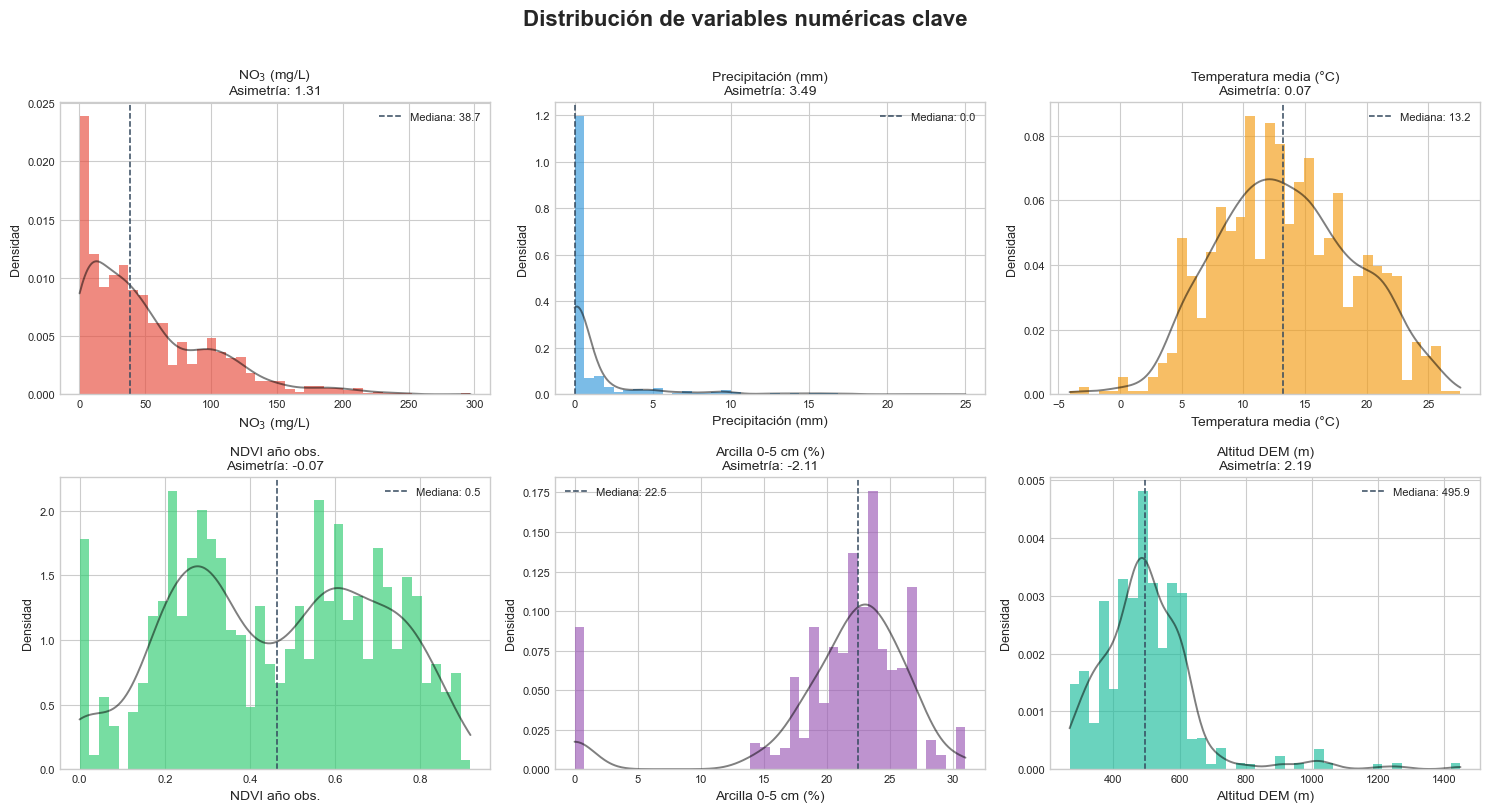

Guardado: eda_1_histogramas.png


In [12]:
FIG_DPI = globals().get('FIG_DPI', 130)  

vars_hist = [
    ('no3_mgl',           'NO$_3$ (mg/L)',           '#e74c3c'),
    ('prec',              'Precipitación (mm)',      '#3498db'),
    ('tmed',              'Temperatura media (°C)',  '#f39c12'),
    ('ndvi_anio_observacion', 'NDVI año obs.',        '#2ecc71'),
    ('soil_clay_0_5cm',   'Arcilla 0-5 cm (%)',      '#9b59b6'),
    ('altitud_dem_m',     'Altitud DEM (m)',          '#1abc9c'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribución de variables numéricas clave', fontsize=16, fontweight='bold', y=1.01)

for ax, (col, label, color) in zip(axes.flat, vars_hist):
    serie = df[col].dropna()
    ax.hist(serie, bins=40, color=color, alpha=0.65, density=True, edgecolor='none')
    kde_x = np.linspace(serie.min(), serie.max(), 300)
    kde = stats.gaussian_kde(serie)
    ax.plot(kde_x, kde(kde_x), color='black', linewidth=1.4, alpha=0.5)
    ax.axvline(serie.median(), color='#34495e', linestyle='--', linewidth=1.1, label=f'Mediana: {serie.median():.1f}')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Densidad', fontsize=9)
    ax.legend(fontsize=8)
    # Estadísticos en esquina
    skew = serie.skew()
    ax.set_title(f'{label}\nAsimetría: {skew:.2f}', fontsize=10)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('eda_1_histogramas.png', dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
plt.show()
print('Guardado: eda_1_histogramas.png')

**Interpretación**

* NO₃ (mg/L): La mayoría de las muestras están entre 0-50 mg/L, pero hay una "cola larga" hacia valores muy altos (hasta 300 mg/L).
  Asimetría 1.31, muchos puntos normales pero algunos muy contaminados. La mediana es 38.7 mg/L, justo por debajo del umbral de 37.5 mg/L.
  
* Precipitación: Casi todo son días con 0 mm de lluvia (barra enorme a la izquierda). Lo que se mide es precipitación del día del muestreo, no acumulada.

* Temperatura media: Distribución bastante simétrica (asimetría 0.07), centrada en 13.2°C. Refleja bien el clima riojano con sus estaciones.

* NDVI: Distribución bimodal (dos "jorobas"), lo que sugiere dos tipos de puntos: zonas con poca vegetación (aprox 0.2) y zonas con vegetación activa (aprox 0.5-0.6).

* Arcilla 0-5 cm: Asimetría negativa muy fuerte (-2.11), la mayoría de los suelos tienen 20-30% de arcilla con muy pocos extremos. Distribución invertida.

* Altitud DEM: La mayoría de puntos están entre 400-600 m (fondo de valle y riberas), con pocos puntos en zonas altas. Asimetría positiva alta (2.19).

### 2 · Distribución de variables categóricas

> **Grafico de barras**



> *Objetivo:* Frecuencia de cada categoría, desbalances en el target y distribución del uso del suelo. Mostrando el recuento de categorías para entender el reparto del problema.


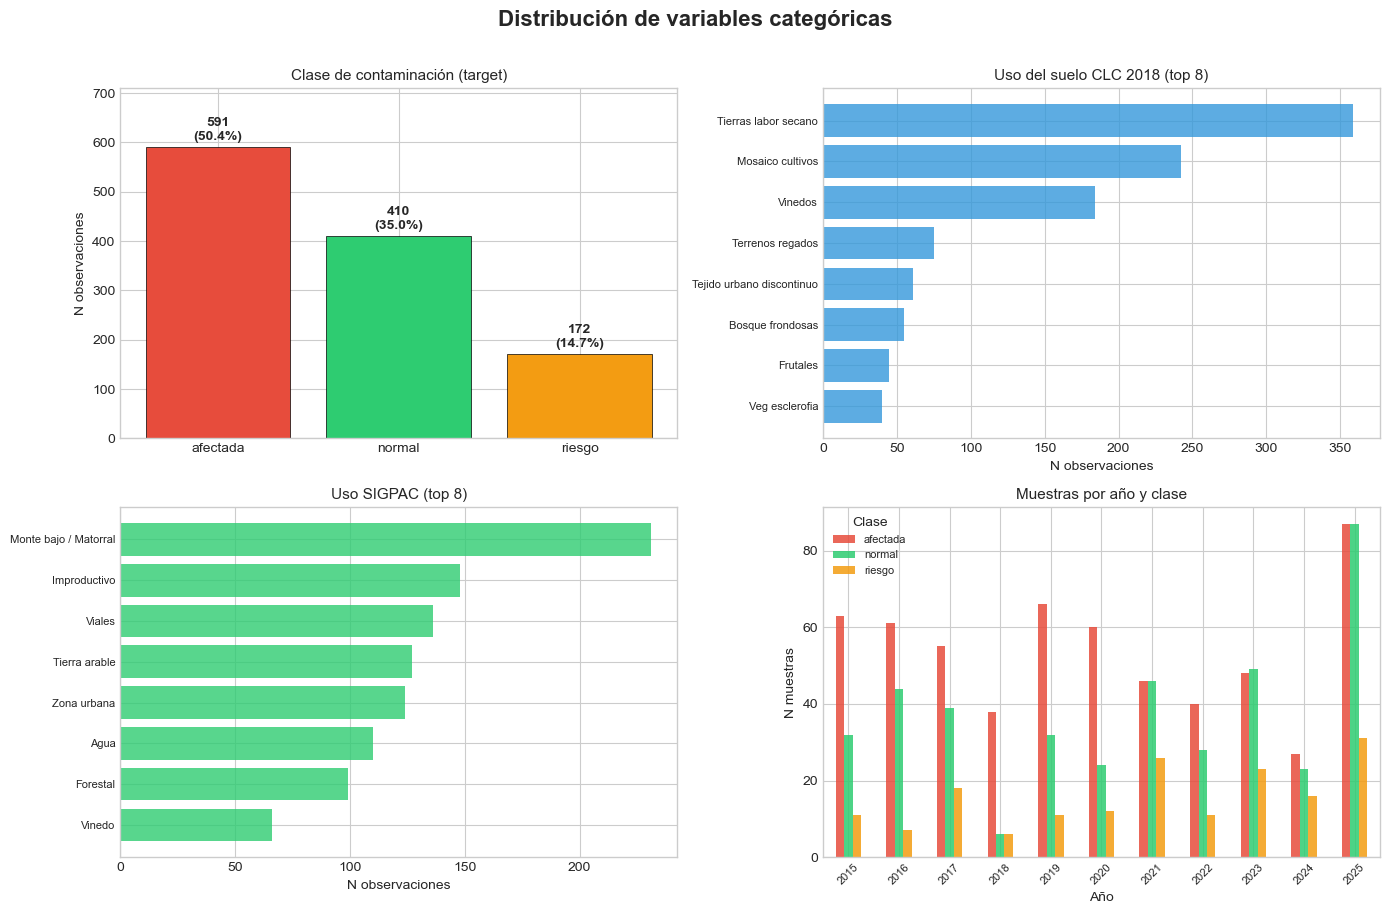

Guardado: eda_2_categoricas.png


In [4]:
FIG_DPI = globals().get('FIG_DPI', 130)
PALETTE = globals().get('PALETTE', {'normal': '#2ecc71', 'riesgo': '#f39c12', 'afectada': '#e74c3c'})


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Distribución de variables categóricas', fontsize=16, fontweight='bold', y=1.01)

# 2a: Target (clase)
ax = axes[0, 0]
vc = df['clase'].value_counts()
colors_clase = [PALETTE.get(c, '#888') for c in vc.index]
bars = ax.bar(vc.index, vc.values, color=colors_clase, edgecolor='black', linewidth=0.5)
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{v}\n({100*v/len(df):.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Clase de contaminación (target)', fontsize=11)
ax.set_ylabel('N observaciones')
ax.set_ylim(0, vc.max() * 1.2)

# 2b: Uso de suelo CLC 2018 
ax = axes[0, 1]
clc = df['clc2018_nombre'].value_counts().head(8)
ax.barh(clc.index[::-1], clc.values[::-1], color='#3498db', alpha=0.8)
ax.set_title('Uso del suelo CLC 2018 (top 8)', fontsize=11)
ax.set_xlabel('N observaciones')
ax.tick_params(axis='y', labelsize=8)

# 2c: Uso SIGPAC 
ax = axes[1, 0]
sigpac = df['sigpac_uso_nombre'].value_counts().head(8)
ax.barh(sigpac.index[::-1], sigpac.values[::-1], color='#2ecc71', alpha=0.8)
ax.set_title('Uso SIGPAC (top 8)', fontsize=11)
ax.set_xlabel('N observaciones')
ax.tick_params(axis='y', labelsize=8)

# 2d: Distribución anual de muestras 
ax = axes[1, 1]
por_anio = df.groupby(['anio', 'clase']).size().unstack(fill_value=0)
por_anio.plot(kind='bar', ax=ax, color=[PALETTE.get(c,'#888') for c in por_anio.columns],
              edgecolor='none', alpha=0.85)
ax.set_title('Muestras por año y clase', fontsize=11)
ax.set_xlabel('Año')
ax.set_ylabel('N muestras')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.legend(title='Clase', fontsize=8)

plt.tight_layout()
plt.savefig('eda_2_categoricas.png', dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
plt.show()
print('Guardado: eda_2_categoricas.png')

**Interpretación**

* Target (clase): El 50.4% de las muestras están "afectadas" (>37.5 mg/L NO₃). Solo el 14.7% en "riesgo" y el 35% normales. Esto es preocupante: más de la mitad de las mediciones superan el umbral normativo.
  
* Uso del suelo CLC 2018: Dominan las "Tierras de labor en secano" y "Mosaico de cultivos", seguidas de viñedos. Confirma que los puntos de muestreo están mayoritariamente en entorno agrícola.

  
* Uso SIGPAC: "Monte bajo/Matorral" e "Improductivo" encabezan la lista, lo que refleja que muchos puntos están en parcelas no cultivadas pero rodeadas de zonas agrícolas.

  
* Muestras por año: La distribución es irregular, con pico notable en 2025 (~80 muestras). Algunos años tienen muy pocas muestras (2018), lo que puede afectar a análisis temporales.

### 3 · Relación entre variables numéricas


> **Scatter plots coloreados por clase**


> *Objetivo:* Patrones de separación entre clases, correlaciones visibles y posibles valores atípicos. Muesta si hay relación visual entre cada variable y la concentración de nitratos, coloreando los puntos por clase.


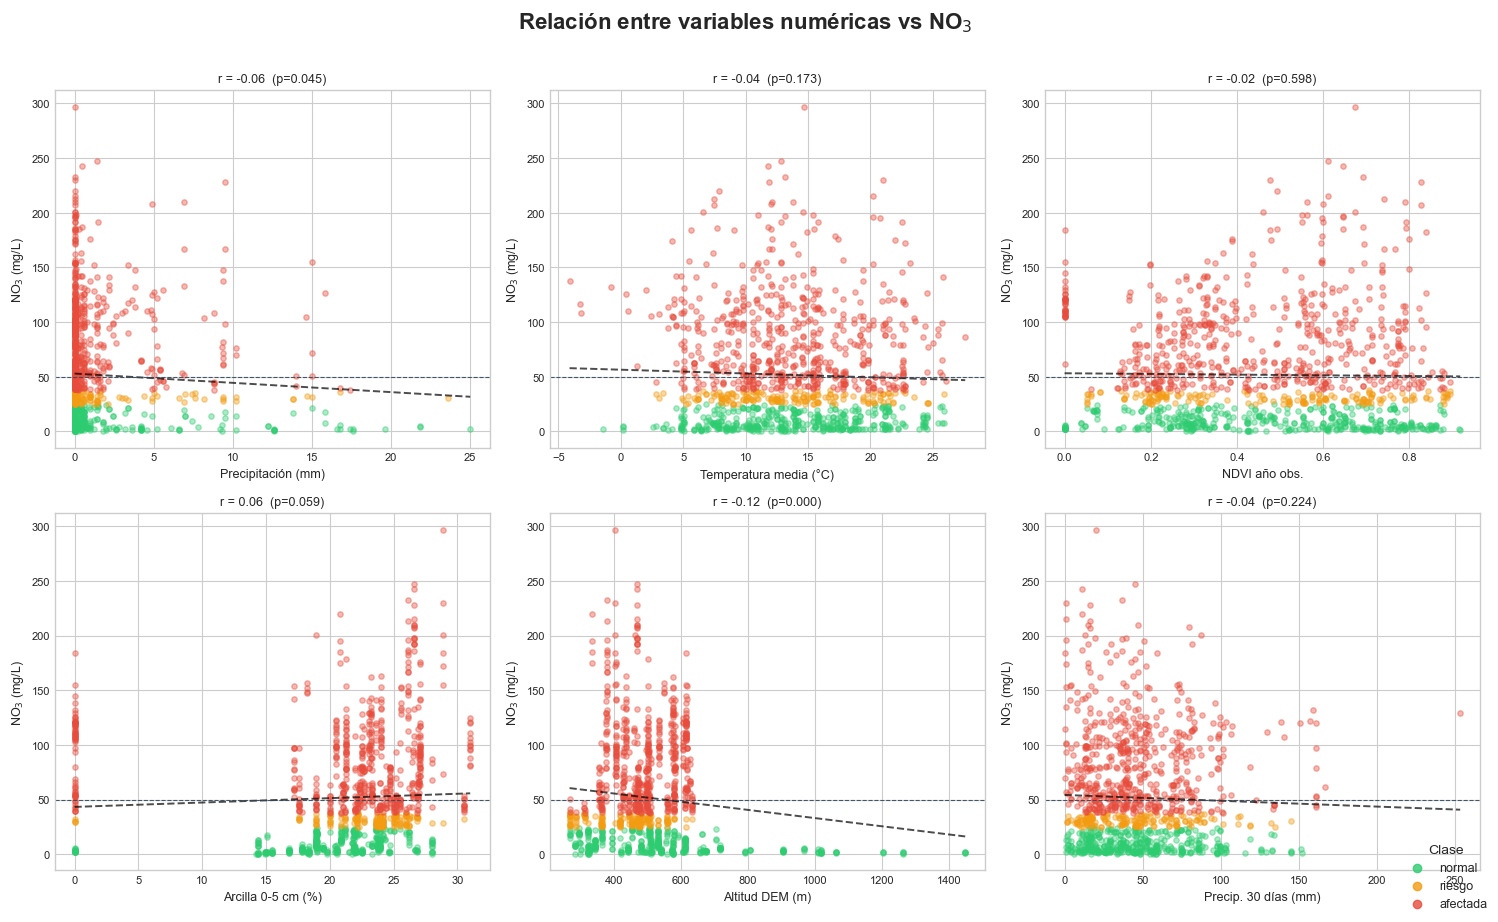

Guardado: eda_3_scatter.png
Línea discontinua = tendencia lineal | Línea punteada = umbral normativo 50 mg/L NO₃


In [12]:
FIG_DPI = globals().get('FIG_DPI', 130)

pares = [
    ('prec',                  'no3_mgl', 'Precipitación (mm)',      'NO$_3$ (mg/L)'),
    ('tmed',                  'no3_mgl', 'Temperatura media (°C)',  'NO$_3$ (mg/L)'),
    ('ndvi_anio_observacion', 'no3_mgl', 'NDVI año obs.',           'NO$_3$ (mg/L)'),
    ('soil_clay_0_5cm',       'no3_mgl', 'Arcilla 0-5 cm (%)',      'NO$_3$ (mg/L)'),
    ('altitud_dem_m',         'no3_mgl', 'Altitud DEM (m)',          'NO$_3$ (mg/L)'),
    ('precip_30d',            'no3_mgl', 'Precip. 30 días (mm)',    'NO$_3$ (mg/L)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Relación entre variables numéricas vs NO$_3$', fontsize=16, fontweight='bold', y=1.01)

for ax, (xcol, ycol, xlabel, ylabel) in zip(axes.flat, pares):
    for clase, color in PALETTE.items():
        mask = df['clase'] == clase
        ax.scatter(df.loc[mask, xcol], df.loc[mask, ycol],
                   c=color, alpha=0.4, s=15, label=clase)
    sub = df[[xcol, ycol]].dropna()
    if len(sub) > 10:
        m, b, r, p, _ = stats.linregress(sub[xcol], sub[ycol])
        xr = np.linspace(sub[xcol].min(), sub[xcol].max(), 100)
        ax.plot(xr, m*xr + b, color='black', linewidth=1.4, linestyle='--', alpha=0.7)
        ax.set_title(f'r = {r:.2f}  (p={p:.3f})', fontsize=9)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(labelsize=8)
    ax.axhline(50, color='#34495e', linewidth=0.8, linestyle='--', alpha=0.9, label='Umbral 50 mg/L')

handles = [plt.scatter([], [], c=c, label=k, alpha=0.8) for k, c in PALETTE.items()]
fig.legend(handles=handles, title='Clase', loc='lower right', fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.savefig('eda_3_scatter.png', dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
plt.show()
print('Guardado: eda_3_scatter.png')
print('Línea discontinua = tendencia lineal | Línea punteada = umbral normativo 50 mg/L NO₃')

**Interpretación:** 

* Precipitación vs NO₃ (r=-0.06): Correlación casi nula, pero los puntos "afectados" (rojos) se acumulan en días de lluvia cero. La lluvia del día de muestreo no explica los nitratos.
* Temperatura vs NO₃ (r=-0.04): Tampoco hay relación lineal clara. Los puntos afectados aparecen en todo el rango de temperaturas.
* NDVI vs NO₃ (r=-0.02): Sin correlación. Los puntos más contaminados tienen NDVI bajo y alto, lo que indica que el problema no depende directamente de la vegetación actual.
* Arcilla vs NO₃ (r=0.06): Correlación positiva muy débil. Ligeramente más nitratos en suelos arcillosos.
* Altitud vs NO₃ (r=-0.12, p<0.001): La correlación más fuerte y significativa: a mayor altitud, menos nitratos. Los puntos afectados se concentran en zonas bajas (400-600 m), que coincide con zonas agrícolas de regadío.
* Precipitación 30 días vs NO₃ (r=-0.04): Sin relación relevante tampoco con la lluvia acumulada.


***Nota**: Ninguna variable individualmente explica bien los nitratos, lo que justifica usar un modelo multivariante.*



---
## 4 · Mapa de calor de correlaciones
### Heatmap de Pearson sobre variables numéricas seleccionadas
 
**Objetivo:** Fuerza y dirección de la relación entre variables. Ideal para detectar multicolinealidad antes del modelado. Entonces va a mostrar la relación entre todas las variables del dataset entre sí. Rojo = correlación positiva fuerte, Azul = correlación negativa fuerte, Blanco/gris = sin relación.


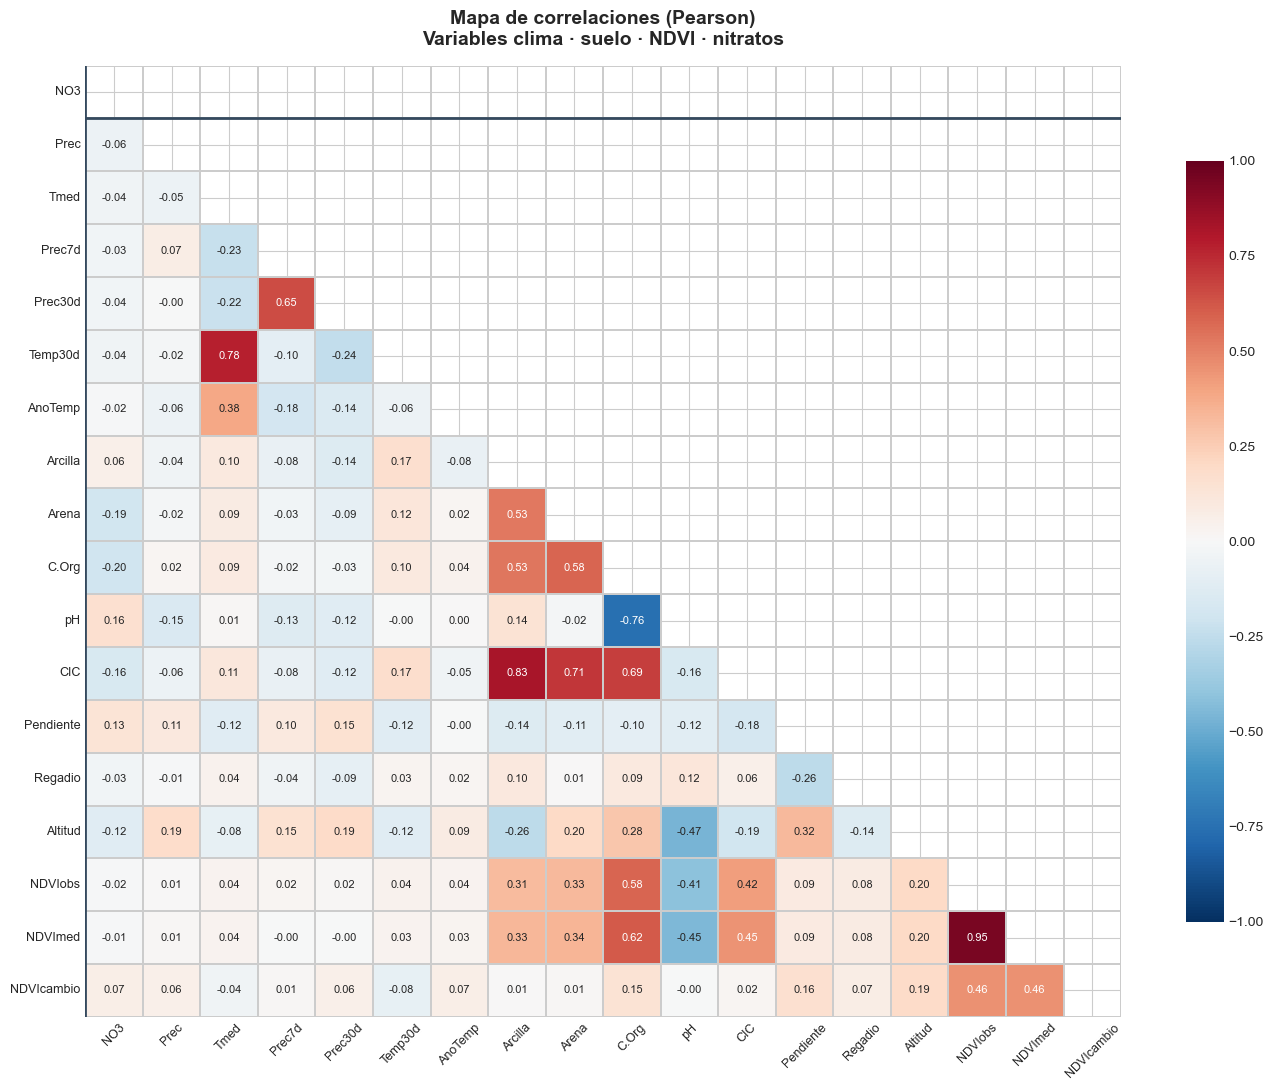

Guardado: eda_4_heatmap.png

Top correlaciones con NO3:
C.Org         0.201455
Arena         0.191622
CIC           0.163384
pH            0.160032
Pendiente     0.134952
Altitud       0.117489
NDVIcambio    0.066112
Prec          0.058676
Arcilla       0.055168
Temp30d       0.042015


In [16]:
FIG_DPI = globals().get('FIG_DPI', 130)
CMAP_CORR = globals().get('CMAP_CORR', 'RdBu_r')
PALETTE   = globals().get('PALETTE', {'normal': '#2ecc71', 'riesgo': '#f39c12', 'afectada': '#e74c3c'})

vars_corr = [
    'no3_mgl',
    'prec', 'tmed', 'precip_7d', 'precip_30d', 'temp_media_30d', 'anomalia_temp',
    'soil_clay_0_5cm', 'soil_sand_0_5cm', 'soil_soc_0_5cm',
    'soil_phh2o_0_5cm', 'soil_cec_0_5cm',
    'sigpac_pendiente_pct', 'sigpac_coef_regadio',
    'altitud_dem_m',
    'ndvi_anio_observacion', 'ndvi_media_periodo', 'ndvi_cambio_periodo',
]
vars_corr = [v for v in vars_corr if v in df.columns]

corr = df[vars_corr].corr()

labels = {
    'no3_mgl': 'NO3', 'prec': 'Prec', 'tmed': 'Tmed',
    'precip_7d': 'Prec7d', 'precip_30d': 'Prec30d',
    'temp_media_30d': 'Temp30d', 'anomalia_temp': 'AnoTemp',
    'soil_clay_0_5cm': 'Arcilla', 'soil_sand_0_5cm': 'Arena',
    'soil_soc_0_5cm': 'C.Org', 'soil_phh2o_0_5cm': 'pH',
    'soil_cec_0_5cm': 'CIC', 'sigpac_pendiente_pct': 'Pendiente',
    'sigpac_coef_regadio': 'Regadio', 'altitud_dem_m': 'Altitud',
    'ndvi_anio_observacion': 'NDVIobs', 'ndvi_media_periodo': 'NDVImed',
    'ndvi_cambio_periodo': 'NDVIcambio',
}
corr.index = [labels.get(v, v) for v in corr.index]
corr.columns = [labels.get(v, v) for v in corr.columns]

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=CMAP_CORR,
            vmin=-1, vmax=1, center=0, ax=ax,
            annot_kws={'size': 8}, linewidths=0.3, linecolor='#cccccc',
            cbar_kws={'shrink': 0.8})
ax.set_title('Mapa de correlaciones (Pearson)\nVariables clima · suelo · NDVI · nitratos',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

# Resaltar columna NO3
ax.axhline(y=1, color='#34495e', linewidth=2)
ax.axvline(x=0, color='#34495e', linewidth=2)

plt.tight_layout()
plt.savefig('eda_4_heatmap.png', dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
plt.show()
print('Guardado: eda_4_heatmap.png')

print('\nTop correlaciones con NO3:')
print(corr['NO3'].drop('NO3').abs().sort_values(ascending=False).head(10).to_string())

**Interpretación:** 

* NO₃ apenas correlaciona con nada individualmente (toda la fila superior está cerca de blanco). Máximo r=-0.19 con Arena y C.Org. Esto confirma que el problema es multifactorial.
* Temperatura media y Temp30d: r=0.78, muy redundantes entre sí (dicen casi lo mismo). Lo mismo con Prec7d y Prec30d (r=0.65).
* Arena y C.Org: r=0.53: los suelos con más arena tienden a tener más carbono orgánico en este dataset.
* pH y C.Org: r=-0.76 : relación muy fuerte: suelos más ácidos tienen más materia orgánica (típico de suelos forestales).
* CIC (capacidad de intercambio catiónico) correlaciona fuerte con Arena (0.83), C.Org (0.69) y pH (-0.16): las variables de suelo forman un bloque muy interrelacionado.
* NDVIobs y NDVImed: r=0.95 : prácticamente la misma información. Para el modelo habrá que elegir una.

***Nota:** Hay grupos de variables redundantes que habrá que gestionar (reducción de dimensionalidad o selección de features).*

---
## 5 · Detección de valores atípicos
### Boxplot por variable y por clase

**Objetivo:** Dispersión, outliers y diferencias entre clases en las variables principales. Se observa que la caja central representa el 50% de los datos, la línea blanca la mediana, y los puntos sueltos son outliers.


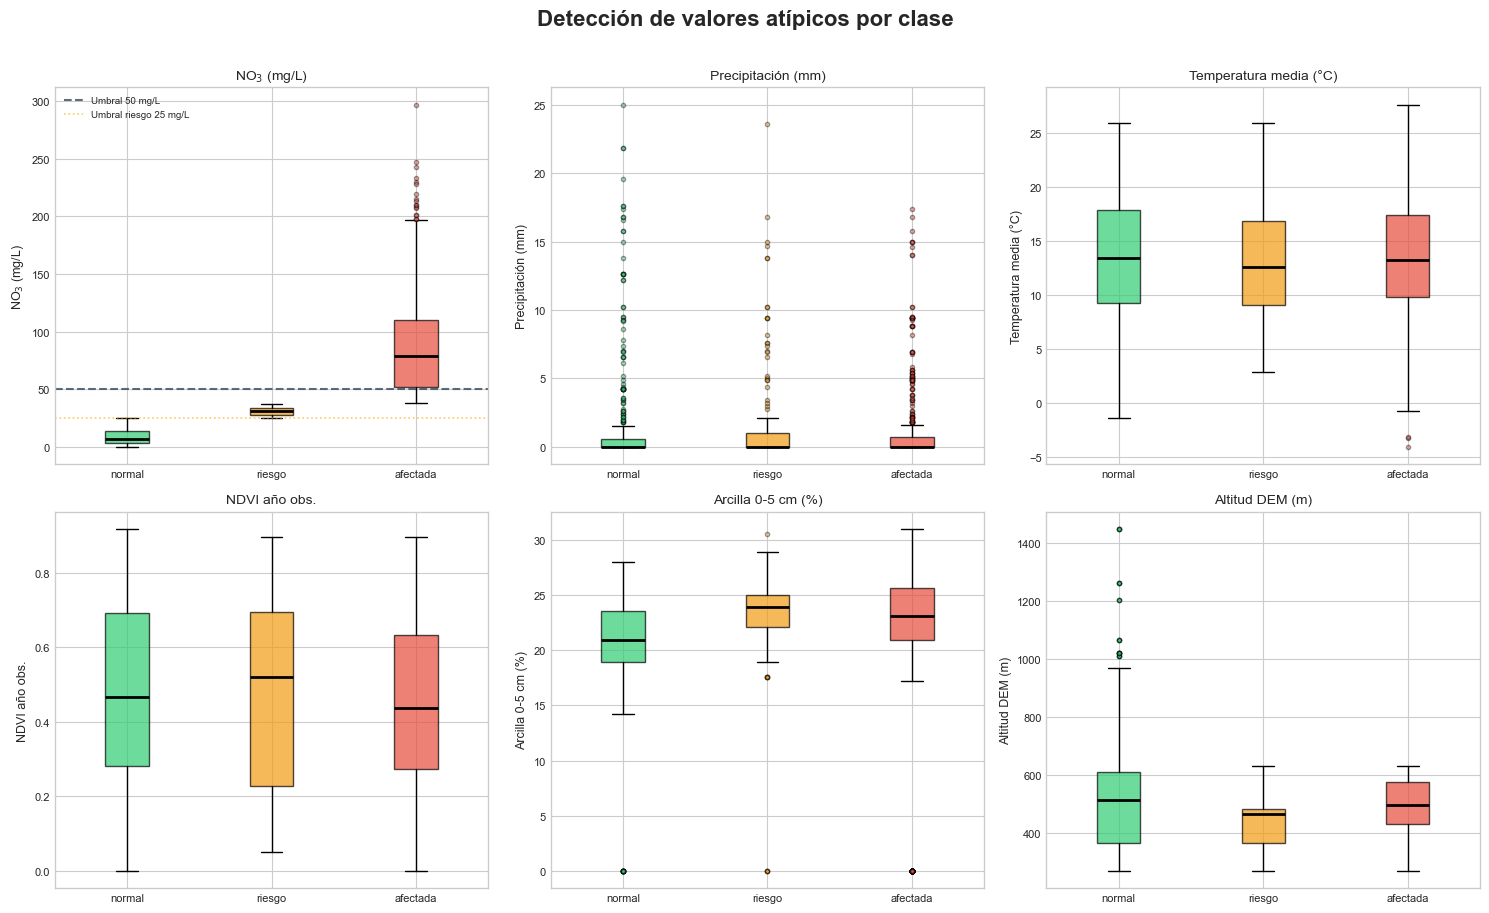

Guardado: eda_5_boxplot.png


In [14]:
FIG_DPI = globals().get('FIG_DPI', 130)

vars_box = [
    ('no3_mgl',               'NO$_3$ (mg/L)'),
    ('prec',                  'Precipitación (mm)'),
    ('tmed',                  'Temperatura media (°C)'),
    ('ndvi_anio_observacion', 'NDVI año obs.'),
    ('soil_clay_0_5cm',       'Arcilla 0-5 cm (%)'),
    ('altitud_dem_m',         'Altitud DEM (m)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Detección de valores atípicos por clase', fontsize=16, fontweight='bold', y=1.01)

orden_clase = ['normal', 'riesgo', 'afectada']
colores = [PALETTE[c] for c in orden_clase]

for ax, (col, label) in zip(axes.flat, vars_box):
    data_plot = [df.loc[df['clase'] == c, col].dropna().values for c in orden_clase]
    bp = ax.boxplot(data_plot, patch_artist=True, notch=False,
                    medianprops={'color': 'black', 'linewidth': 2},
                    whiskerprops={'color': 'black'},
                    capprops={'color': 'black'},
                    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4})
    for patch, color in zip(bp['boxes'], colores):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for flier, color in zip(bp['fliers'], colores):
        flier.set_markerfacecolor(color)
    ax.set_xticklabels(orden_clase, fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.tick_params(labelsize=8)
    if col == 'no3_mgl':
        ax.axhline(50, color='#34495e', linestyle='--', linewidth=1.5, alpha=0.8, label='Umbral 50 mg/L')
        ax.axhline(25, color='orange', linestyle=':', linewidth=1.2, alpha=0.6, label='Umbral riesgo 25 mg/L')
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('eda_5_boxplot.png', dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
plt.show()
print('Guardado: eda_5_boxplot.png')

**Interpretación:** 

* NO₃ por clase: Las tres cajas están bien separadas, confirmando que la clasificación tiene sentido. La clase "afectada" tiene mediana aprox 80 mg/L y outliers hasta 260 mg/L. Hay puntos "normales" con NO₃ casi en 0, y puntos "afectados" con valores extremísimos.
* Precipitación: Las tres clases tienen distribuciones muy similares, sin diferencia entre afectadas y normales, la lluvia del día no distingue la contaminación.
* Temperatura: Tampoco hay diferencias entre clases, confirma lo del scatter (dispersión).
* NDVI: Las zonas "normales" tienen NDVI ligeramente más alto (mediana aprox 0.5) que las "afectadas" (aprox 0.45). Diferencia pequeña pero perceptible.
* Arcilla: Las zonas "afectadas" tienen ligeramente más arcilla (mediana aprox 23%) que las "normales" (aprox 22%). Diferencia mínima.
* Altitud: Aquí sí hay diferencia clara: los puntos "riesgo" están a menor altitud (mediana aprox 420 m) que los "normales" (aprox 480 m). Las zonas bajas de regadío acumulan más nitratos.

---
## 6 · Tendencia en el tiempo
### Evolución temporal de NO₃ y variables climáticas

**Objetivo:** Comportamientos temporales, estacionalidad, cambios de tendencia y correlación visual entre nitratos y clima. Mostrar cómo han evolucionado los nitratos y las variables climáticas a lo largo de 10 años.


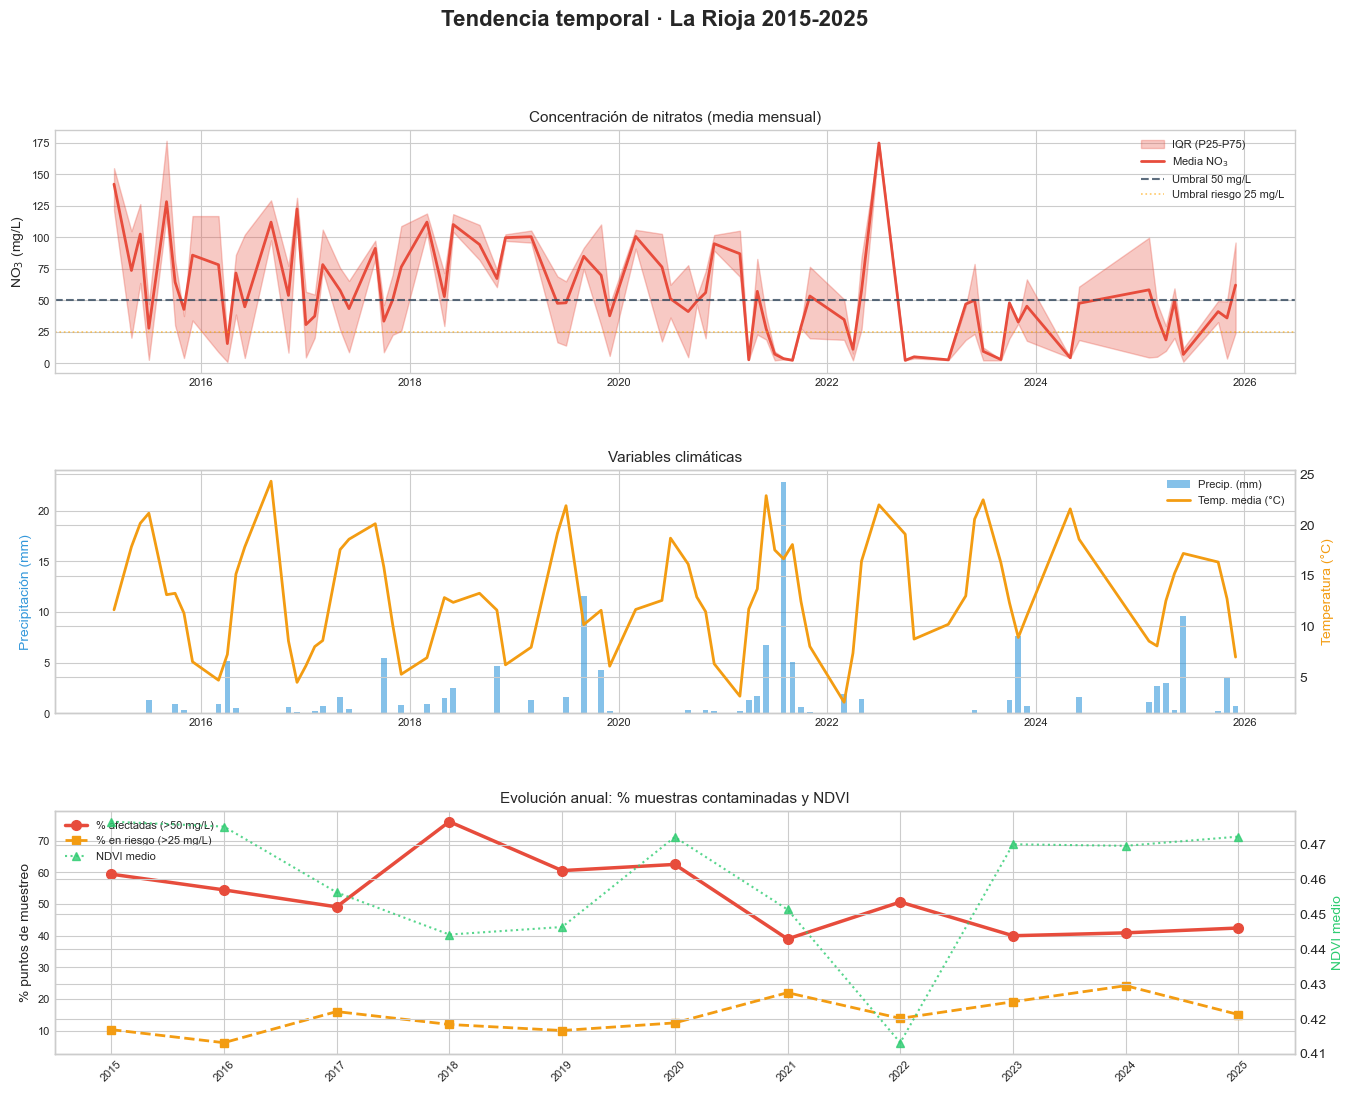

Guardado: eda_6_temporal.png


In [15]:
FIG_DPI = globals().get('FIG_DPI', 130)

df_time = df.groupby(['anio', 'mes']).agg(
    no3_media=('no3_mgl', 'mean'),
    no3_p75=('no3_mgl', lambda x: x.quantile(0.75)),
    no3_p25=('no3_mgl', lambda x: x.quantile(0.25)),
    prec_media=('prec', 'mean'),
    tmed_media=('tmed', 'mean'),
    pct_afectada=('afectada', 'mean'),
    n=('no3_mgl', 'count')
).reset_index()
df_time['fecha_mes'] = pd.to_datetime(
    df_time[['anio', 'mes']].rename(columns={'anio':'year','mes':'month'}).assign(day=1))
df_time = df_time.sort_values('fecha_mes')

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 1, hspace=0.4)
fig.suptitle('Tendencia temporal · La Rioja 2015-2025', fontsize=16, fontweight='bold')

# ── Panel 1: NO3 con banda intercuartil ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.fill_between(df_time['fecha_mes'], df_time['no3_p25'], df_time['no3_p75'],
                 alpha=0.3, color='#e74c3c', label='IQR (P25-P75)')
ax1.plot(df_time['fecha_mes'], df_time['no3_media'],
         color='#e74c3c', linewidth=2, label='Media NO$_3$')
ax1.axhline(50, color='#34495e', linestyle='--', linewidth=1.5, alpha=0.8, label='Umbral 50 mg/L')
ax1.axhline(25, color='orange', linestyle=':', linewidth=1.2, alpha=0.6, label='Umbral riesgo 25 mg/L')
ax1.set_ylabel('NO$_3$ (mg/L)', fontsize=10)
ax1.set_title('Concentración de nitratos (media mensual)', fontsize=11)
ax1.legend(fontsize=8, loc='upper right')
ax1.tick_params(labelsize=8)

# ── Panel 2: Precipitación y temperatura ────────────────────────────────────
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2b = ax2.twinx()
ax2.bar(df_time['fecha_mes'], df_time['prec_media'], width=20,
        color='#3498db', alpha=0.6, label='Precip. (mm)')
ax2b.plot(df_time['fecha_mes'], df_time['tmed_media'],
          color='#f39c12', linewidth=2, label='Temp. media (°C)')
ax2.set_ylabel('Precipitación (mm)', fontsize=10, color='#3498db')
ax2b.set_ylabel('Temperatura (°C)', fontsize=10, color='#f39c12')
ax2.set_title('Variables climáticas', fontsize=11)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')
ax2.tick_params(labelsize=8)

# ── Panel 3: % muestras afectadas por año ───────────────────────────────────
ax3 = fig.add_subplot(gs[2])
df_anio = df.groupby('anio').agg(
    pct_afectada=('afectada', lambda x: 100*x.mean()),
    pct_riesgo=('en_riesgo', lambda x: 100*x.mean()),
    ndvi_medio=('ndvi_anio_observacion', 'mean')
).reset_index()
ax3.plot(df_anio['anio'], df_anio['pct_afectada'], 'o-',
         color='#e74c3c', linewidth=2.5, markersize=7, label='% afectadas (>50 mg/L)')
ax3.plot(df_anio['anio'], df_anio['pct_riesgo'], 's--',
         color='#f39c12', linewidth=2, markersize=6, label='% en riesgo (>25 mg/L)')
ax3b = ax3.twinx()
ax3b.plot(df_anio['anio'], df_anio['ndvi_medio'], '^:',
          color='#2ecc71', linewidth=1.5, markersize=6, alpha=0.8, label='NDVI medio')
ax3.set_ylabel('% puntos de muestreo', fontsize=10)
ax3b.set_ylabel('NDVI medio', fontsize=10, color='#2ecc71')
ax3.set_title('Evolución anual: % muestras contaminadas y NDVI', fontsize=11)
ax3.set_xticks(df_anio['anio'])
ax3.tick_params(axis='x', rotation=45, labelsize=8)
ax3.tick_params(axis='y', labelsize=8)
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

plt.savefig('eda_6_temporal.png', dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
plt.show()
print('Guardado: eda_6_temporal.png')

**Interpretación:** 

* Panel superior (NO₃ mensual): La media de nitratos ha estado sistemáticamente por encima del umbral de 50 mg/L durante casi todo el período, con un pico muy destacado en 2022. A partir de 2023-2024 se observa una ligera bajada de la media. La banda rojiza (IQR) es muy amplia, indicando alta variabilidad entre puntos.
* Panel central (clima): La precipitación diaria es casi siempre muy baja (días secos), con algún pico ocasional. La temperatura sigue el patrón estacional esperado con máximos en verano (aprox 22°C) y mínimos en invierno (aprox 5°C).
* Panel inferior (% contaminados por año): El porcentaje de puntos afectados (>50 mg/L) ha oscilado entre el 40-70%, con máximo en 2018 (aprox 70%). No se observa tendencia clara de mejora a lo largo de los 10 años. El NDVI medio muestra una ligera tendencia ascendente desde 2022, posiblemente asociada a años más húmedos.
    

---
## Resumen estadístico
### Tabla de estadísticos descriptivos por clase

In [13]:
vars_resumen = ['no3_mgl', 'prec', 'tmed', 'precip_30d',
                'ndvi_anio_observacion', 'soil_clay_0_5cm',
                'soil_soc_0_5cm', 'altitud_dem_m']
vars_resumen = [v for v in vars_resumen if v in df.columns]

resumen = df.groupby('clase')[vars_resumen].agg(['mean','median','std']).round(2)
resumen.columns = ['_'.join(c) for c in resumen.columns]

print('=== Estadísticos descriptivos por clase ===')
print(resumen.T.to_string())

print('\n=== Porcentaje de nulos por variable clave ===')
nulos = df[vars_resumen].isnull().mean().mul(100).round(1)
print(nulos.to_string())

=== Estadísticos descriptivos por clase ===
clase                         afectada  normal  riesgo
no3_mgl_mean                     87.45    9.22   30.82
no3_mgl_median                   78.80    7.25   30.90
no3_mgl_std                      43.36    6.95    3.40
prec_mean                         1.16    1.59    1.58
prec_median                       0.00    0.00    0.00
prec_std                          2.69    3.93    3.65
tmed_mean                        13.54   13.67   13.30
tmed_median                      13.20   13.40   12.55
tmed_std                          5.53    5.68    5.14
precip_30d_mean                  46.65   47.30   44.47
precip_30d_median                40.20   43.40   39.20
precip_30d_std                   32.89   31.55   30.47
ndvi_anio_observacion_mean        0.45    0.47    0.48
ndvi_anio_observacion_median      0.44    0.47    0.52
ndvi_anio_observacion_std         0.23    0.24    0.25
soil_clay_0_5cm_mean             21.19   20.14   22.96
soil_clay_0_5cm_media

**Conclusiones:** 

* El análisis exploratorio del dataset integrado de La Rioja (2015-2025, n=1.173 observaciones, 101 puntos de muestreo) revela que más del 50% de las muestras de agua subterránea superan el umbral normativo de nitratos (37.5 mg/L, RD 47/2022), una situación que se ha mantenido sin mejora significativa durante la última década.

* Desde el punto de vista de las variables explicativas, ningún factor individual presenta una correlación lineal fuerte con la concentración de nitratos, siendo la altitud la que muestra la relación más consistente (r=-0.12, p<0.001): los puntos situados en zonas bajas de regadío acumulan sistemáticamente concentraciones más elevadas. Las variables climáticas diarias (precipitación, temperatura) no discriminan entre puntos contaminados y no contaminados, mientras que las variables de suelo presentan alta multicolinealidad interna (especialmente pH, carbono orgánico y CIC), lo que requiere una cuidadosa selección de variables previa al modelado.

* Estos resultados justifican el uso de un modelo de clasificación multivariante capaz de capturar interacciones no lineales entre los bloques de variables (clima, suelo, uso del suelo, NDVI y altitud), con especial atención al desbalance de clases (clase "riesgo" = 14.7%) mediante estrategias como class_weight=balanced.